# Loss anchor — setting `w_m` by measurement

**What this notebook produces: one number, `w_m`, to paste into
`experiments/configs/bsrnn_baseline.yaml`.**

The present-branch loss adds two scores together:

    L_present = L_pres + w_m * L_MR

`L_pres` is SI-SDR, in decibels. `L_MR` is an average absolute error over STFT
magnitudes. They judge the same output but in unrelated units, so adding them raw
is like adding a top speed to a fuel economy. `w_m` is the exchange rate between
them.

The way to find that rate is to score one fixed, agreed answer with both judges
and see what each of them says. The answer used here is **"do nothing"** — submit
the mixture unchanged, as if it were the model's output. That point is chosen
because:

* it needs no model, so it can be computed before training starts;
* it gives the same numbers on every run — no seed, no random init;
* it is roughly where a real model sits after a few hundred steps.

An untrained model would *not* work as the anchor: its output is noise shaped by
the random init, so the rate derived from it would be a property of the seed.

Implements `docs/decisions/decisions-m1.md`, 2026-08-20, section "`w_m` is set by
measurement, not by sweep". The provisional `w_m ~ 6.6` recorded there came from a
single crop; this notebook is the few-hundred-crop version of the same
measurement.

`w`, the weight on the absent half, needs no anchor — it is fixed at 0.458 by
arithmetic in the same entry.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import soundfile as sf
import subprocess
import time
import yaml
from datetime import date

torch.set_grad_enabled(False)          # re-enabled locally for the gradient section
device = torch.device("cpu")           # the anchor is model-free; a GPU buys nothing

# --- make `src.*` importable from this notebook -------------------------------
# Mirrors the sys.path.insert that scripts/ use. Walks up for CLAUDE.md so it
# works regardless of where the kernel was started.
import sys
from pathlib import Path as _Path

_root = _Path.cwd()
while not (_root / "CLAUDE.md").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f"repo root on sys.path: {_root}")

repo root on sys.path: /home/grant/Documents/University/Masters/Project/TargetSpeakerExtractor


In [15]:
# Load configs
def load_config(model_yaml="bsrnn_baseline.yaml", repo_root=None):
    root = Path(repo_root or Path.cwd())
    while not (root / "CLAUDE.md").exists() and root != root.parent:
        root = root.parent
    cfgs = root / "experiments" / "configs"

    model = yaml.safe_load((cfgs / model_yaml).read_text())
    gen   = yaml.safe_load((cfgs / "generator.yaml").read_text())

    # Single source of truth: the rate the data was rendered at.
    model["sample_rate"] = gen["sample_rate"]
    return model, root

cfg, ROOT = load_config()
sr      = cfg["sample_rate"]
seed    = cfg["seed"]
chunk_s = cfg["data"]["chunk_s"]

# The `loss:` block does not exist yet -- writing it is the OUTPUT of this
# notebook. Until it does, the terms carry the values recorded in
# decisions-m1.md 2026-08-20; `w_m` is the one being measured, so its value here
# is irrelevant (every call below uses the per-term methods directly).
loss_cfg = cfg.get("loss", {})
if not loss_cfg:
    print("no `loss:` block in bsrnn_baseline.yaml yet -- using decisions-m1.md values")
LOSS_TAU     = loss_cfg.get("tau", 0.001)
LOSS_W       = loss_cfg.get("w", 0.458)          # absent half, fixed by arithmetic
LOSS_P       = loss_cfg.get("p", 0.3)            # magnitude compression
LOSS_WINDOWS = tuple(loss_cfg.get("windows_ms", (8, 16, 32, 64)))

print(f"sr={sr}  chunk_s={chunk_s}  seed={seed}")
print(f"tau={LOSS_TAU}  w={LOSS_W}  p={LOSS_P}  windows_ms={LOSS_WINDOWS}")

no `loss:` block in bsrnn_baseline.yaml yet -- using decisions-m1.md values
sr=16000  chunk_s=4.0  seed=42
tau=0.001  w=0.458  p=0.3  windows_ms=(8, 16, 32, 64)


## 1. One crop, to see what the two judges say

Nothing is trained here. Both loss terms are plain functions of two waveforms —
what the answer should be (`target.wav`) and what was submitted. Normally the
submission is the model's output, but the code does not care what it is handed,
so we hand it `mixture.wav`.

The crop offset is drawn from the dataset's own RNG from `(seed, epoch, idx)`, so
the exact number below will differ from the `-5.605 / 0.2535` logged in
decisions-m1.md — that was a different window of the same trial. It should land
in the same region.

In [16]:
from src.data.dataset_loader import TrialDataset
from src.models.losses import LossBSRNN

ds = TrialDataset(
    manifest_csv=ROOT / "data/manifests/train.csv",
    data_root=ROOT / "data",
    split="train",
    chunk_s=chunk_s,
    sample_rate=sr,
    seed=seed,
    random_crop=True,
)

# wm is passed but never used below: every call goes to the per-term methods,
# never to __call__, precisely because wm is what we are here to determine.
loss = LossBSRNN(wm=1.0, w=LOSS_W, p=LOSS_P, tau=LOSS_TAU,
                 windows=LOSS_WINDOWS, sample_rate=sr)

TRIAL = "train-42-010130"          # the crop logged in decisions-m1.md 2026-08-20
hits  = ds.manifest_df.index[ds.manifest_df["trial_id"] == TRIAL]
idx   = int(hits[0]) if len(hits) else 0

item   = ds[idx]
target = item["target"].unsqueeze(0)      # (1, T) -- the loss wants a batch dim
mixture= item["mixture"].unsqueeze(0)     # (1, T) -- the "do nothing" submission
assert not item["crop_absent"], "this crop has no target speech; L_pres is NaN by design"

l_pres = float(loss._loss_target_present(target, mixture, loss.tau)[0])
l_mr   = float(loss._loss_multi_res_stft(target, mixture, loss.windows, loss.p)[0])

print(f"trial      {item['trial_id']}  ({item['meta']['condition']}, "
      f"sir {item['meta']['sir_db']:+.1f} dB, regime {item['meta']['regime']})")
print(f"L_pres     {l_pres:8.3f}   dB   (0 = submitted silence, -30 = perfect)")
print(f"L_MR       {l_mr:8.4f}        (0 = perfect, bigger = worse)")
print(f"\nraw sum with w_m = 1: L_MR is {l_mr / (abs(l_pres) + l_mr):.1%} of the total")

trial      train-42-010130  (both, sir -0.1 dB, regime hard)
L_pres       -3.328   dB   (0 = submitted silence, -30 = perfect)
L_MR         0.2799        (0 = perfect, bigger = worse)

raw sum with w_m = 1: L_MR is 7.8% of the total


Two numbers, same submission, no shared scale:

| term | what it is | perfect | did nothing |
| --- | --- | --- | --- |
| `L_pres` | SI-SDR in dB, floored at `tau` | -30 | about -5 to -6, i.e. the mixture's own SI-SDR |
| `L_MR` | mean absolute error over compressed STFT magnitudes | 0 | about 0.25 |

The last line printed above is the problem `w_m` exists to fix: left at CARTSE's
`w_m = 1`, the spectral term contributes a few percent of the score and is
effectively not in the loss.

## 2. The same measurement on a few hundred crops

One crop is not a defensible number. `L_pres` on the do-nothing submission is
roughly the mixture's own SIR, which the data generator controls, so it sits in a
narrow band. `L_MR` does not — it depends on how bright or busy that particular
clip is, and can read very differently trial to trial. So: measure both on a few
hundred crops and take the median of each.

Crops where the target is silent are skipped, not scored: `L_pres` is `0/0` there,
a NaN by design (decisions-m1.md, "Tests to keep"). Their share is printed as a
free cross-check on the 0.297 crop-level absent rate measured on 2026-08-18.

In [ ]:
def measure_anchor(ds, loss, n_crops=300, epoch=0, sample_seed=0):
    """Score the do-nothing submission on `n_crops` present crops.

    Reads mixture and target with a windowed read and takes the crop offset from
    the dataset's own RNG, so these are the exact windows training will see --
    not a fresh sample of the audio.

    Returns (per-crop DataFrame, n_absent skipped, wall seconds).
    """
    rng   = np.random.default_rng(sample_seed)
    order = rng.permutation(len(ds))
    ds.set_epoch(epoch)

    rows, n_absent = [], 0
    t0 = time.perf_counter()

    for i in order:
        if len(rows) >= n_crops:
            break
        i = int(i)
        row = ds.manifest_df.iloc[i]
        target_dir = ds.data_root / "rendered" / ds.split / row["trial_id"]

        n_frames = sf.info(str(target_dir / "mixture.wav")).frames
        start    = ds._crop_offset_start(i, n_frames)

        target = ds._read_in_wav(target_dir / "target.wav", start=start, frames=ds.chunk_frames)
        if target.abs().max() == 0:                  # absent crop: L_pres is a NaN here
            n_absent += 1
            continue
        mixture = ds._read_in_wav(target_dir / "mixture.wav", start=start, frames=ds.chunk_frames)

        t, m = target.unsqueeze(0), mixture.unsqueeze(0)
        rows.append({
            "trial_id":   row["trial_id"],
            "condition":  row["condition"],
            "regime":     row["regime"],
            "sir_db":     float(row["sir_db"]),
            "snr_db":     float(row["snr_db"]),
            "t60_s":      float(row["t60_s"]),
            "activity":   float(row["target_activity"]),
            "L_pres":     float(loss._loss_target_present(t, m, loss.tau)[0]),
            "L_MR":       float(loss._loss_multi_res_stft(t, m, loss.windows, loss.p)[0]),
        })

    wall = time.perf_counter() - t0
    print(f"{len(rows)} present crops scored in {wall:.1f}s "
          f"({wall / max(len(rows), 1) * 1000:.0f} ms/crop, single-threaded)")
    print(f"{n_absent} absent crops skipped "
          f"({n_absent / max(n_absent + len(rows), 1):.3f} of those drawn; "
          f"decisions-m1.md 2026-08-18 measured 0.297)")
    return pd.DataFrame(rows), n_absent, wall


df, n_absent, wall = measure_anchor(ds, loss, n_crops=300)
df.head()

300 present crops scored in 4.1s (14 ms/crop, single-threaded)
134 absent crops skipped (0.309 of those drawn; decisions-m1.md 2026-08-18 measured 0.297)


,trial_id,condition,regime,sir_db,snr_db,t60_s,activity,L_pres,L_MR
0,train-42-003219,both,hard,-0.48,13.97,0.4406,0.6288,5.027866,0.308825
1,train-42-006103,both,hard,-4.40,16.70,0.3153,0.7565,3.557916,0.409580
2,train-42-003014,both,hard,12.00,14.74,0.2671,0.6709,-13.081694,0.090022
3,train-42-011847,target_only,hard,NaN,16.41,0.5022,0.4751,-11.975064,0.181383
4,train-42-014444,both,base,11.43,18.54,0.3392,0.5622,-20.064848,0.096366


In [18]:
# L_MR should be worth about this fraction of |L_pres| at the anchor. A judgement
# call, not a derived quantity -- which is exactly why w_m is ablated at
# {0, 0.3x, 1.0x} (decisions-m1.md 2026-08-20).
RATIO_TARGET = 0.3

med_pres, med_mr = df["L_pres"].median(), df["L_MR"].median()
w_m = RATIO_TARGET * abs(med_pres) / med_mr

# Two ways to combine, reported together because they answer slightly different
# questions: the ratio of medians is the weight for a typical batch, the median of
# per-crop ratios is the weight that balances the typical *crop*.
w_m_per_crop = float((RATIO_TARGET * df["L_pres"].abs() / df["L_MR"]).median())

print(f"L_pres   median {med_pres:8.3f}   IQR [{df.L_pres.quantile(.25):.3f}, "
      f"{df.L_pres.quantile(.75):.3f}]   spread {df.L_pres.std():.3f}")
print(f"L_MR     median {med_mr:8.4f}   IQR [{df.L_MR.quantile(.25):.4f}, "
      f"{df.L_MR.quantile(.75):.4f}]   spread {df.L_MR.std():.4f}")
print(f"\nw_m from the medians      {w_m:6.2f}")
print(f"w_m median of per-crop    {w_m_per_crop:6.2f}")
print(f"single crop, 2026-08-20     6.60   (provisional, decisions-m1.md)")

print("\nwhat each candidate makes L_MR worth, as a share of the present branch:")
for name, cand in [("w_m = 0 (ablation arm)", 0.0),
                   ("w_m = 1 (CARTSE)", 1.0),
                   ("w_m measured", w_m)]:
    share = cand * med_mr / (abs(med_pres) + cand * med_mr)
    print(f"  {name:24s} w_m={cand:6.2f}   share={share:6.1%}")

L_pres   median   -5.909   IQR [-10.894, -1.621]   spread 9.079
L_MR     median   0.1842   IQR [0.1321, 0.2699]   spread 0.1217

w_m from the medians        9.62
w_m median of per-crop     10.54
single crop, 2026-08-20     6.60   (provisional, decisions-m1.md)

what each candidate makes L_MR worth, as a share of the present branch:
  w_m = 0 (ablation arm)   w_m=  0.00   share=  0.0%
  w_m = 1 (CARTSE)         w_m=  1.00   share=  3.0%
  w_m measured             w_m=  9.62   share= 23.1%


How to read the block above: the measured `w_m` should put `L_MR` at roughly
`RATIO_TARGET` of the branch, and CARTSE's `1.0` should come out near a few
percent — that gap is the whole justification for not inheriting their weight.

Also worth noting for the write-up: `L_MR`'s spread relative to its median should
be visibly larger than `L_pres`'s. That is the reason this is a median over
hundreds of crops rather than the single measurement it started as.

**Record the final numbers in `decisions-m1.md`** — the section currently says
"provisional until run over a few hundred crops and medianed", and this is that
run.

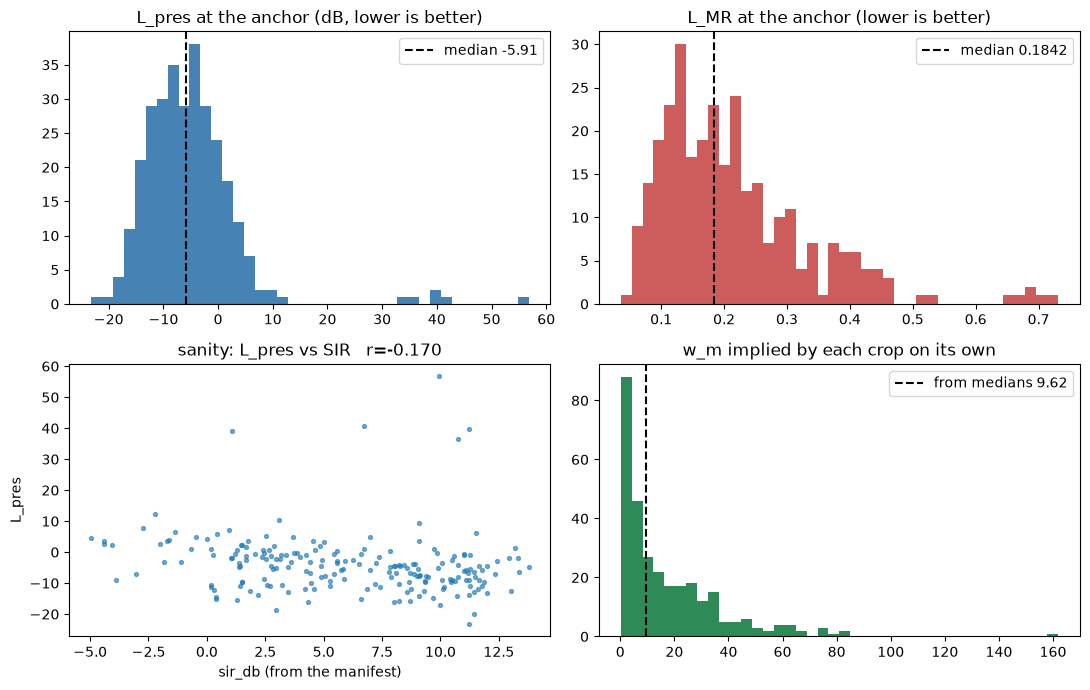

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

ax[0, 0].hist(df["L_pres"], bins=40, color="steelblue")
ax[0, 0].axvline(med_pres, color="k", ls="--", label=f"median {med_pres:.2f}")
ax[0, 0].set_title("L_pres at the anchor (dB, lower is better)")
ax[0, 0].legend()

ax[0, 1].hist(df["L_MR"], bins=40, color="indianred")
ax[0, 1].axvline(med_mr, color="k", ls="--", label=f"median {med_mr:.4f}")
ax[0, 1].set_title("L_MR at the anchor (lower is better)")
ax[0, 1].legend()

# L_pres on a do-nothing submission IS the mixture's own SI-SDR, so it should
# track sir_db closely. A weak relationship here means something is wrong.
ax[1, 0].scatter(df["sir_db"], df["L_pres"], s=8, alpha=0.6)
ax[1, 0].set_xlabel("sir_db (from the manifest)")
ax[1, 0].set_ylabel("L_pres")
ax[1, 0].set_title(f"sanity: L_pres vs SIR   r={df.sir_db.corr(df.L_pres):+.3f}")

implied = RATIO_TARGET * df["L_pres"].abs() / df["L_MR"]
ax[1, 1].hist(implied, bins=40, color="seagreen")
ax[1, 1].axvline(w_m, color="k", ls="--", label=f"from medians {w_m:.2f}")
ax[1, 1].set_title("w_m implied by each crop on its own")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

● "At the anchor" is just shorthand for "on the do-nothing submission" — every number in those plots comes from scoring s_output = mixture against target.wav. One crop in, two scores out; 300 crops gives you 300 pairs, and the plots are the spread of those pairs. Nothing is trained, so there's no notion of "before/after" — the anchor is a single fixed operating point.

Top-left — L_pres at the anchor. How badly doing nothing scores on the SI-SDR judge, one bar-count per crop. Expect a bump around -5 to -6 dB, fairly tight. What it tells you: the range that judge actually operates over on your data, which is what the exchange rate has to be scaled against.

Top-right — L_MR at the anchor. The same 300 crops on the spectral judge. Expect a median near 0.25, but wider relative to its own median than the left panel. That width is the entire reason this is a 300-crop median instead of the single measurement it started as — if this histogram is narrow, one crop would have been fine and the notebook is overkill.

Bottom-left — the sanity check. This one isn't about w_m at all; it's the only panel that can fail. When the submission is the mixture, L_pres is mathematically just the mixture's own SI-SDR — so it should track sir_db, the level ratio your generator was asked to produce. Louder target → mixture is already closer to the answer → better (more negative) L_pres, so the trend should slope downward and r should come out clearly negative. If it comes out flat, something upstream is wrong rather than the loss:  mismatched target.wav/mixture.wav pairing, crop offsets applied to one file but not the other, or the rendered levels not matching what the manifest claims. Free check on the data pipeline, and cheap to have.

Expect real scatter around the trend, though, and don't read that as a fault. sir_db is a whole-clip number; your crop is 4 s of it. A crop that happens to land where the target speaks alone scores far better than the clip's SIR implies — which is the same overlap variation you measured back in M0.


  Bottom-right — the implied w_m. For each crop on its own, compute 0.3 × |L_pres| 
  / L_MR — the rate you'd have picked if that were the only crop you ever looked
  at. The histogram is those 300 answers. This is the panel that says how much your
  w_m depends on luck of the draw: the provisional 6.6 in decisions-m1.md is one
  sample from this distribution, and the dashed line is what you get from the
  medians instead.







  Two things to look for. A wide spread justifies the medianing. Two humps would be
  the interesting outcome — it'd mean one constant is averaging over two genuinely
  different kinds of trial, which is what the groupby in section 3 goes looking
  for, and it'd be a limitation to state rather than smooth over.

  One footnote on why the dashed line and the histogram's own median won't quite
  agree: median(a)/median(b) isn't median(a/b). Neither is wrong — the ratio of
  medians balances a typical batch, the median of ratios balances a typical crop.
  Print both, pick the ratio of medians for the config since that's what the doc
  specifies, and note the other.

  Worth saying plainly: those "expect" numbers are what the arithmetic and the one
  logged crop predict, not measurements. The notebook hasn't been run.

## 3. Is one exchange rate enough for every kind of trial?

`w_m` is a single constant in the config, so it is worth knowing whether the rate
it implies is stable across the data or whether it is really several different
numbers averaged together. If the implied `w_m` swings hard between, say, the
`base` and `hard` regimes, that is a limitation to state, not something to hide
inside a median.

In [20]:
d = df.copy()
d["implied_w_m"] = RATIO_TARGET * d["L_pres"].abs() / d["L_MR"]
d["sir_bucket"]  = pd.cut(d["sir_db"], [-99, -3, 0, 3, 99],
                          labels=["target much quieter", "quieter", "louder", "much louder"])

for by in ["regime", "condition", "sir_bucket"]:
    g = (d.groupby(by, observed=True)
           .agg(n=("L_pres", "size"),
                L_pres=("L_pres", "median"),
                L_MR=("L_MR", "median"),
                implied_w_m=("implied_w_m", "median"))
           .round({"L_pres": 3, "L_MR": 4, "implied_w_m": 2}))
    print(f"--- by {by} ---")
    print(g.to_string(), "\n")

--- by regime ---
          n  L_pres    L_MR  implied_w_m
regime                                  
base    196  -7.500  0.1689        14.18
hard    104  -3.211  0.2282         4.23 

--- by condition ---
               n  L_pres    L_MR  implied_w_m
condition                                    
both         203  -4.532  0.2097         7.18
target_only   97  -8.778  0.1545        19.42 

--- by sir_bucket ---
                       n  L_pres    L_MR  implied_w_m
sir_bucket                                           
target much quieter    6   2.508  0.4273         2.79
quieter               10   3.833  0.3451         3.33
louder                47  -2.055  0.2213         5.01
much louder          140  -5.909  0.1983         9.78 



## 4. How hard does each judge pull? (gradient norms)

Matching the two *scores* is a stand-in for matching how hard each term pulls on
the weights during training — and it is only a stand-in. Two terms can read the
same size and still push with very different force.

So, at the same anchor, take the gradient of each term with respect to the
submitted waveform and compare the norms. The waveform rather than the weights,
because there is no model at the anchor and the waveform is the only thing both
terms share.

decisions-m1.md flags this as a caveat to report: no paper in
`review_synthesis.md` reports per-term gradient norms, so this is a small
original observation rather than a replication.

In [21]:
def grad_norms(ds, loss, w_m, n=20, epoch=0, sample_seed=1):
    """Per-term gradient norm wrt the submitted waveform, at the do-nothing anchor.

    `L_MR`'s norm is reported both raw and scaled by w_m -- the scaled one is what
    training actually applies.
    """
    rng   = np.random.default_rng(sample_seed)
    order = rng.permutation(len(ds))
    ds.set_epoch(epoch)

    rows = []
    with torch.enable_grad():                    # the notebook runs with grad off
        for i in order:
            if len(rows) >= n:
                break
            i = int(i)
            r    = ds.manifest_df.iloc[i]
            tdir = ds.data_root / "rendered" / ds.split / r["trial_id"]
            start = ds._crop_offset_start(i, sf.info(str(tdir / "mixture.wav")).frames)

            tgt = ds._read_in_wav(tdir / "target.wav", start=start, frames=ds.chunk_frames)
            if tgt.abs().max() == 0:
                continue
            mix = ds._read_in_wav(tdir / "mixture.wav", start=start, frames=ds.chunk_frames)
            t   = tgt.unsqueeze(0)

            # A separate leaf per term: one backward pass each, no shared graph.
            s1 = mix.unsqueeze(0).clone().requires_grad_(True)
            g1 = torch.autograd.grad(loss._loss_target_present(t, s1, loss.tau).sum(), s1)[0]

            s2 = mix.unsqueeze(0).clone().requires_grad_(True)
            g2 = torch.autograd.grad(
                loss._loss_multi_res_stft(t, s2, loss.windows, loss.p).sum(), s2)[0]

            rows.append({
                "trial_id":     r["trial_id"],
                "g_pres":       float(g1.norm()),
                "g_mr_raw":     float(g2.norm()),
                "g_mr_scaled":  float(w_m * g2.norm()),
            })

    out = pd.DataFrame(rows)
    out["ratio"] = out["g_mr_scaled"] / out["g_pres"]
    return out


gn = grad_norms(ds, loss, w_m, n=20)
print(gn[["g_pres", "g_mr_raw", "g_mr_scaled", "ratio"]].median().round(6).to_string())
print(f"\nscore ratio we aimed for:     {RATIO_TARGET:.2f}")
print(f"gradient ratio actually seen: {gn['ratio'].median():.2f}")
print("\nIf these two disagree badly, say so in decisions-m1.md rather than "
      "adjusting w_m to chase the gradient -- the weight was defined on scores.")

g_pres         3.026640
g_mr_raw       0.272056
g_mr_scaled    2.618062
ratio          1.164321

score ratio we aimed for:     0.30
gradient ratio actually seen: 1.16

If these two disagree badly, say so in decisions-m1.md rather than adjusting w_m to chase the gradient -- the weight was defined on scores.


## 5. Why the spectral judge is in the loss at all

A check worth having in the notebook because it is the argument for the term's
existence, and it is direct thesis material.

Take the *clean target* and delete everything above 1 kHz — a muffled mumble,
every consonant gone. Almost all the energy survives, so `L_pres` scores it
generously. `L_MR` does not.

**What this does and does not show.** It shows that the two terms disagree
sharply about high-frequency destruction, which is why one weight cannot be
inherited from a paper with different data. It does *not* show that the measured
`w_m` makes the muffled signal lose outright — both terms still rate it above
doing nothing. `w_m` sets how much say the spectral term gets, not a veto. What
tests whether the term earns its place is the `w_m = 0` ablation arm.

In [22]:
def brickwall(x, sr, cutoff_hz, n_fft=512):
    """Delete everything above `cutoff_hz`. Analysis-synthesis, center=True.

    Offline on purpose: this is a diagnostic, not the model's streaming front end,
    so causality does not apply (same reasoning as the loss's own STFT).
    """
    win = torch.hann_window(n_fft)
    kw  = dict(n_fft=n_fft, hop_length=n_fft // 4, win_length=n_fft, window=win, center=True)
    X = torch.stft(x, return_complex=True, **kw)
    k = int(round(cutoff_hz * n_fft / sr))
    X[:, k + 1:, :] = 0
    return torch.istft(X, length=x.shape[-1], **kw)


rows = []
for cut in (1000, 4000):
    lp = brickwall(target.clone(), sr, cut)
    rows.append({
        "submission":   f"target, >{cut} Hz deleted",
        "energy_kept":  float(lp.pow(2).sum() / target.pow(2).sum()),
        "L_pres":       float(loss._loss_target_present(target, lp, loss.tau)[0]),
        "L_MR":         float(loss._loss_multi_res_stft(target, lp, loss.windows, loss.p)[0]),
    })
rows.append({"submission": "the mixture (did nothing)", "energy_kept": float("nan"),
             "L_pres": l_pres, "L_MR": l_mr})
rows.append({"submission": "the target itself (perfect)", "energy_kept": 1.0,
             "L_pres": float(loss._loss_target_present(target, target, loss.tau)[0]),
             "L_MR":   float(loss._loss_multi_res_stft(target, target, loss.windows, loss.p)[0])})

probe = pd.DataFrame(rows)
probe["present_branch"] = probe["L_pres"] + w_m * probe["L_MR"]
print(probe.round(4).to_string(index=False))
print("\nRead the L_pres column against the L_MR column, not the total: the point "
      "is that they rank the muffled signal differently.")

                 submission  energy_kept   L_pres   L_MR  present_branch
   target, >1000 Hz deleted       0.9776 -16.2422 0.1707        -14.5993
   target, >4000 Hz deleted       0.9861 -18.2137 0.0916        -17.3323
  the mixture (did nothing)          NaN  -3.3281 0.2799         -0.6343
the target itself (perfect)       1.0000 -30.0000 0.0000        -30.0000

Read the L_pres column against the L_MR column, not the total: the point is that they rank the muffled signal differently.


## 6. Save the result, then update the config

Two outputs. The result directory is the thesis record — config, commit, seed,
date, per-crop numbers. The printed YAML block is what goes into
`experiments/configs/bsrnn_baseline.yaml`, which closes consequences 1 and 4 of
the 2026-08-20 entry: every weight and the reduction convention live in the
config, none of them in the loss module.

In [23]:
def git_commit():
    """Current commit, marked `-dirty` if the tree has uncommitted changes.
    CLAUDE.md requires the hash alongside every generated artefact."""
    try:
        head  = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True,
                               text=True, cwd=ROOT).stdout.strip()
        dirty = subprocess.run(["git", "status", "--porcelain"], capture_output=True,
                               text=True, cwd=ROOT).stdout.strip()
        return f"{head}-dirty" if dirty else head
    except Exception:
        return "unknown"

manifest_meta = yaml.safe_load((ROOT / "data/manifests/train.meta.yaml").read_text())

outdir = ROOT / "experiments/results" / f"{date.today().isoformat()}-loss-anchor"
outdir.mkdir(parents=True, exist_ok=True)
df.to_csv(outdir / "per_crop.csv", index=False)
gn.to_csv(outdir / "grad_norms.csv", index=False)

meta = {
    "date":       date.today().isoformat(),
    "script":     "src/models/loss_anchor.ipynb",
    "git_commit": git_commit(),
    "seed":       seed,
    "config":     "experiments/configs/bsrnn_baseline.yaml",
    "manifest":   "data/manifests/train.csv",
    "manifest_built_at_commit": manifest_meta.get("git_commit"),
    "anchor":     "s_hat = x (the mixture passed through unchanged)",
    "n_present_crops": int(len(df)),
    "n_absent_skipped": int(n_absent),
    "absent_rate_observed": round(n_absent / max(n_absent + len(df), 1), 4),
    "wall_seconds": round(wall, 1),
    "loss_terms": {"tau": LOSS_TAU, "p": LOSS_P, "windows_ms": list(LOSS_WINDOWS)},
    "ratio_target": RATIO_TARGET,
    "results": {
        "L_pres_median": round(float(med_pres), 4),
        "L_pres_iqr":    [round(float(df.L_pres.quantile(.25)), 4),
                          round(float(df.L_pres.quantile(.75)), 4)],
        "L_MR_median":   round(float(med_mr), 5),
        "L_MR_iqr":      [round(float(df.L_MR.quantile(.25)), 5),
                          round(float(df.L_MR.quantile(.75)), 5)],
        "w_m_from_medians":  round(float(w_m), 3),
        "w_m_median_percrop": round(float(w_m_per_crop), 3),
        "w_m_single_crop_2026_08_20": 6.6,
        "grad_norm_median_pres":      round(float(gn.g_pres.median()), 6),
        "grad_norm_median_mr_scaled": round(float(gn.g_mr_scaled.median()), 6),
        "grad_ratio_median":          round(float(gn.ratio.median()), 3),
    },
}
(outdir / "meta.yaml").write_text(yaml.safe_dump(meta, sort_keys=False))
print(f"wrote {outdir.relative_to(ROOT)}/  (per_crop.csv, grad_norms.csv, meta.yaml)")

# Anything over a minute gets a run_times.md row; record() skips it if under.
from src.run_log import record
record("src/models/loss_anchor.ipynb -- measure_anchor()",
       f"{len(df)} present crops, `train`, do-nothing anchor",
       wall,
       rate=f"{wall / max(len(df), 1) * 1000:.0f} ms/crop, single-threaded, 4 STFT pairs each")

wrote experiments/results/2026-08-20-loss-anchor/  (per_crop.csv, grad_norms.csv, meta.yaml)


False

In [24]:
# Paste this into experiments/configs/bsrnn_baseline.yaml.
print(f"""loss:
  # M2 objective, decisions-m1.md 2026-08-20. Six deviations from CARTSE
  # recorded there; the deviations are in src/models/losses.py, the numbers here.
  w:     {LOSS_W}          # weight on the absent half. Deviation 5: 0.297 absent
                    # rate carried through CARTSE's eta = 2.0
  w_m:   {w_m:.2f}          # weight on L_MR inside the present branch. MEASURED at
                    # the do-nothing anchor over {len(df)} crops, {date.today().isoformat()}:
                    # L_pres {med_pres:.3f} dB, L_MR {med_mr:.4f}, target ratio {RATIO_TARGET}
  tau:   {LOSS_TAU}        # floor on both halves: caps the reward at 30 dB
  p:     {LOSS_P}          # magnitude compression, Yu et al. Interspeech 2023 eq (3)
  windows_ms: {list(LOSS_WINDOWS)}   # multi-resolution window set, straddles the
                    # model's own 32 ms framing (Deviation 6)
  complex_term: real_plus_imag   # L1(real) + L1(imag), NOT the modulus. eq (3)
                                 # leaves the complex term uncompressed
  reduction:    mean             # over (F, N) only, never over the batch --
                                 # the masked means need per-example values
  ablate_w_m:   [0.0, {0.3 * w_m:.2f}, {w_m:.2f}]   # the 0 arm is required""")

loss:
  # M2 objective, decisions-m1.md 2026-08-20. Six deviations from CARTSE
  # recorded there; the deviations are in src/models/losses.py, the numbers here.
  w:     0.458          # weight on the absent half. Deviation 5: 0.297 absent
                    # rate carried through CARTSE's eta = 2.0
  w_m:   9.62          # weight on L_MR inside the present branch. MEASURED at
                    # the do-nothing anchor over 300 crops, 2026-08-20:
                    # L_pres -5.909 dB, L_MR 0.1842, target ratio 0.3
  tau:   0.001        # floor on both halves: caps the reward at 30 dB
  p:     0.3          # magnitude compression, Yu et al. Interspeech 2023 eq (3)
  windows_ms: [8, 16, 32, 64]   # multi-resolution window set, straddles the
                    # model's own 32 ms framing (Deviation 6)
  complex_term: real_plus_imag   # L1(real) + L1(imag), NOT the modulus. eq (3)
                                 # leaves the complex term uncompressed
  reduction:    mean             #